# Task 1: Data Sourcing, Understanding & Cleaning
**Dataset:** IBM Telco Customer Churn (Kaggle: [https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset]
Covers Day 3-4 (sourcing and understanding) and Day 5-6 (cleaning and preprocessing).

## Day 3-4: Data Sourcing & Understanding

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW = Path("../data/raw/Telco-Customer-Churn.csv")
PROCESSED = Path("../data/processed/telco_churn_clean.csv")
LOG_PATH = Path("../reports/cleaning_log.csv")

df = pd.read_csv(RAW)
df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Shape:", df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [7]:
# Auto-generated data dictionary: fill in the descriptions yourself
data_dict = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "example": df.iloc[0],
})
data_dict

,dtype,n_unique,n_missing,example
customerID,object,7043,0,7590-VHVEG
gender,object,2,0,Female
SeniorCitizen,int64,2,0,0
Partner,object,2,0,Yes
Dependents,object,2,0,No
tenure,int64,73,0,1
PhoneService,object,2,0,No
MultipleLines,object,3,0,No phone service
InternetService,object,3,0,DSL
OnlineSecurity,object,3,0,No


### Data source, collection method & limitations
- **Source:** IBM sample dataset, hosted on Kaggle. Each row is one telecom customer; the target is `Churn` (Yes/No).
- **Collection method:** Sample data published by IBM to demonstrate analytics tools. It is a synthetic/fictional snapshot, not live company data.
- **Limitations:** Single snapshot with no time dimension; no customer location or support-call data; results may not generalise to real telecom customers.
- **Data quirk found:** `TotalCharges` loads as text because some values are blank spaces.

## Day 5-6: Data Cleaning & Preprocessing

In [8]:
df_clean = df.copy()
log = []

def record(step, action, affected):
    log.append({"step": step, "action": action, "affected": affected})

### 1. Missing values

In [9]:
# Blank strings are hiding missing values in TotalCharges
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
n_missing = int(df_clean["TotalCharges"].isna().sum())
print("Missing after conversion:\n", df_clean.isna().sum()[lambda s: s > 0])

# These rows have tenure == 0 (brand-new customers)
print(df_clean.loc[df_clean["TotalCharges"].isna(), ["tenure", "MonthlyCharges"]].head())

# Median is robust to skew, so use it to fill
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(df_clean["TotalCharges"].median())
record("Missing values", "Converted TotalCharges to numeric; filled blanks with median", n_missing)

Missing after conversion:
 TotalCharges    11
dtype: int64
      tenure  MonthlyCharges
488        0           52.55
753        0           20.25
936        0           80.85
1082       0           25.75
1340       0           56.05


### 2. Duplicates

In [10]:
n_dup = int(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
record("Duplicates", "Dropped exact duplicate rows", n_dup)
print("Duplicates removed:", n_dup)

Duplicates removed: 0


### 3. Data types

In [11]:
# SeniorCitizen is 0/1 but really a Yes/No category
df_clean["SeniorCitizen"] = df_clean["SeniorCitizen"].map({0: "No", 1: "Yes"})

cat_cols = df_clean.select_dtypes(include="object").columns.drop("customerID")
df_clean[cat_cols] = df_clean[cat_cols].astype("category")
record("Data types", "SeniorCitizen 0/1 -> No/Yes; object columns -> category", len(cat_cols) + 1)
df_clean.dtypes

customerID            object
gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn               category
dtype: object

### 4. Outliers (IQR method)

In [12]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    lo, hi = iqr_bounds(df_clean[col])
    n_out = int(((df_clean[col] < lo) | (df_clean[col] > hi)).sum())
    print(f"{col}: bounds=({lo:.1f}, {hi:.1f}), outliers={n_out}")
    record("Outliers", f"IQR check on {col}: {n_out} outliers found; kept (valid customer values)", n_out)

tenure: bounds=(-60.0, 124.0), outliers=0
MonthlyCharges: bounds=(-46.0, 171.4), outliers=0
TotalCharges: bounds=(-4674.3, 8863.2), outliers=0


Outliers were counted but **not removed**, since high charges are legitimate customers, not errors. Note this in your README.

### 5. Standardize column names

In [13]:
df_clean.columns = (
    df_clean.columns
    .str.replace(r"(?<=[a-z])(?=[A-Z])", "_", regex=True)
    .str.lower()
)
record("Column names", "Converted to snake_case", len(df_clean.columns))
list(df_clean.columns)

['customer_id',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'churn']

### 6. Cleaning log & save

In [14]:
log_df = pd.DataFrame(log)
log_df

,step,action,affected
0,Missing values,Converted TotalCharges to numeric; filled blan...,11
1,Duplicates,Dropped exact duplicate rows,0
2,Data types,SeniorCitizen 0/1 -> No/Yes; object columns ->...,18
3,Outliers,IQR check on tenure: 0 outliers found; kept (v...,0
4,Outliers,IQR check on MonthlyCharges: 0 outliers found;...,0
5,Outliers,IQR check on TotalCharges: 0 outliers found; k...,0
6,Column names,Converted to snake_case,21


In [15]:
PROCESSED.parent.mkdir(parents=True, exist_ok=True)
LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(PROCESSED, index=False)
log_df.to_csv(LOG_PATH, index=False)
print("Saved:", PROCESSED, "|", LOG_PATH, "| final shape:", df_clean.shape)

Saved: ..\data\processed\telco_churn_clean.csv | ..\reports\cleaning_log.csv | final shape: (7043, 21)


---
## Day 7-8: Exploratory Data Analysis (EDA)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

df_eda = df_clean.copy()
df_eda["churn_flag"] = (df_eda["churn"] == "Yes").astype(int)
df_eda["senior_flag"] = (df_eda["senior_citizen"] == "Yes").astype(int)
num_cols = ["tenure", "monthly_charges", "total_charges"]

### 1. Statistical summary

In [17]:
df_eda.describe()

,tenure,monthly_charges,total_charges,churn_flag,senior_flag
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928,0.265370,0.162147
std,24.559481,30.090047,2265.270398,0.441561,0.368612
min,0.000000,18.250000,18.800000,0.000000,0.000000
25%,9.000000,35.500000,402.225000,0.000000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000,0.000000
max,72.000000,118.750000,8684.800000,1.000000,1.000000


In [18]:
df_eda.describe(include="category").T

,count,unique,top,freq
gender,7043,2,Male,3555
senior_citizen,7043,2,No,5901
partner,7043,2,No,3641
dependents,7043,2,No,4933
phone_service,7043,2,Yes,6361
multiple_lines,7043,3,No,3390
internet_service,7043,3,Fiber optic,3096
online_security,7043,3,No,3498
online_backup,7043,3,No,3088
device_protection,7043,3,No,3095


In [19]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   customer_id        7043 non-null   object  
 1   gender             7043 non-null   category
 2   senior_citizen     7043 non-null   category
 3   partner            7043 non-null   category
 4   dependents         7043 non-null   category
 5   tenure             7043 non-null   int64   
 6   phone_service      7043 non-null   category
 7   multiple_lines     7043 non-null   category
 8   internet_service   7043 non-null   category
 9   online_security    7043 non-null   category
 10  online_backup      7043 non-null   category
 11  device_protection  7043 non-null   category
 12  tech_support       7043 non-null   category
 13  streaming_tv       7043 non-null   category
 14  streaming_movies   7043 non-null   category
 15  contract           7043 non-null   category
 16  paperl

In [20]:
for col in ["churn", "contract", "internet_service", "payment_method"]:
    print(f"--- {col} ---")
    print(df_eda[col].value_counts(), "\n")
print("Churn share (%):")
print(df_eda["churn"].value_counts(normalize=True).mul(100).round(1))

--- churn ---
churn
No     5174
Yes    1869
Name: count, dtype: int64 

--- contract ---
contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64 

--- internet_service ---
internet_service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

--- payment_method ---
payment_method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64 

Churn share (%):
churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


### 2. Univariate analysis

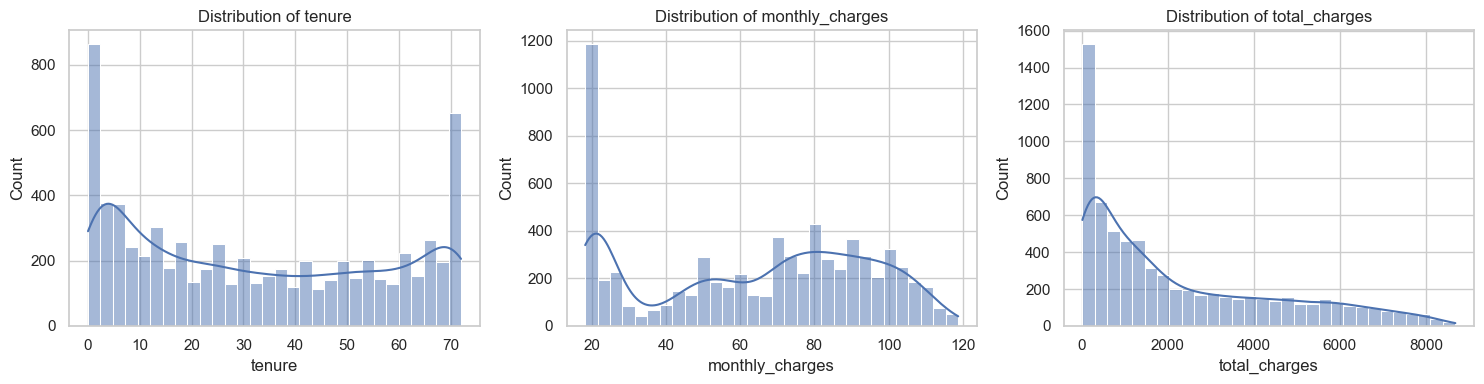

In [21]:
# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df_eda[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
save_fig("hist_numeric")

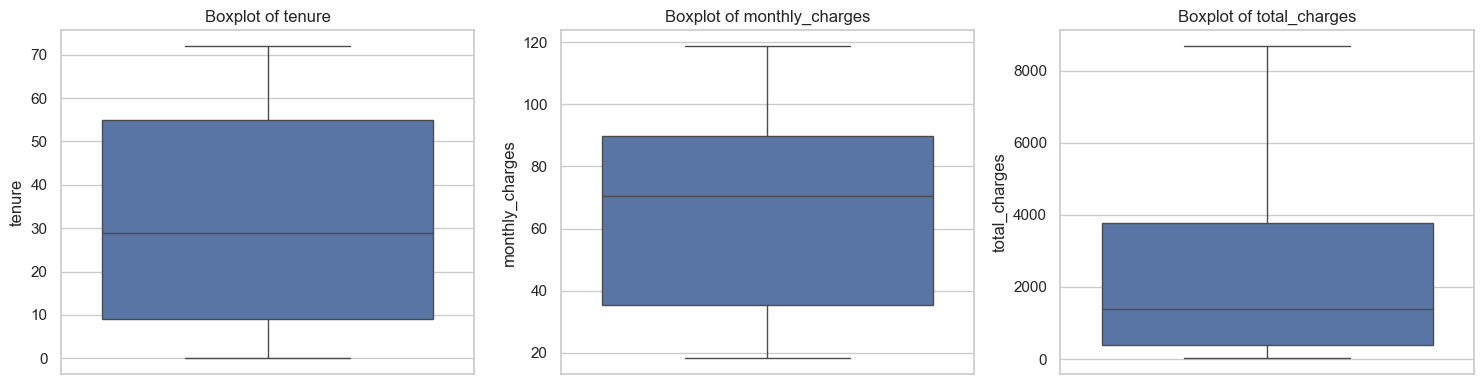

In [22]:
# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df_eda[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")
save_fig("box_numeric")

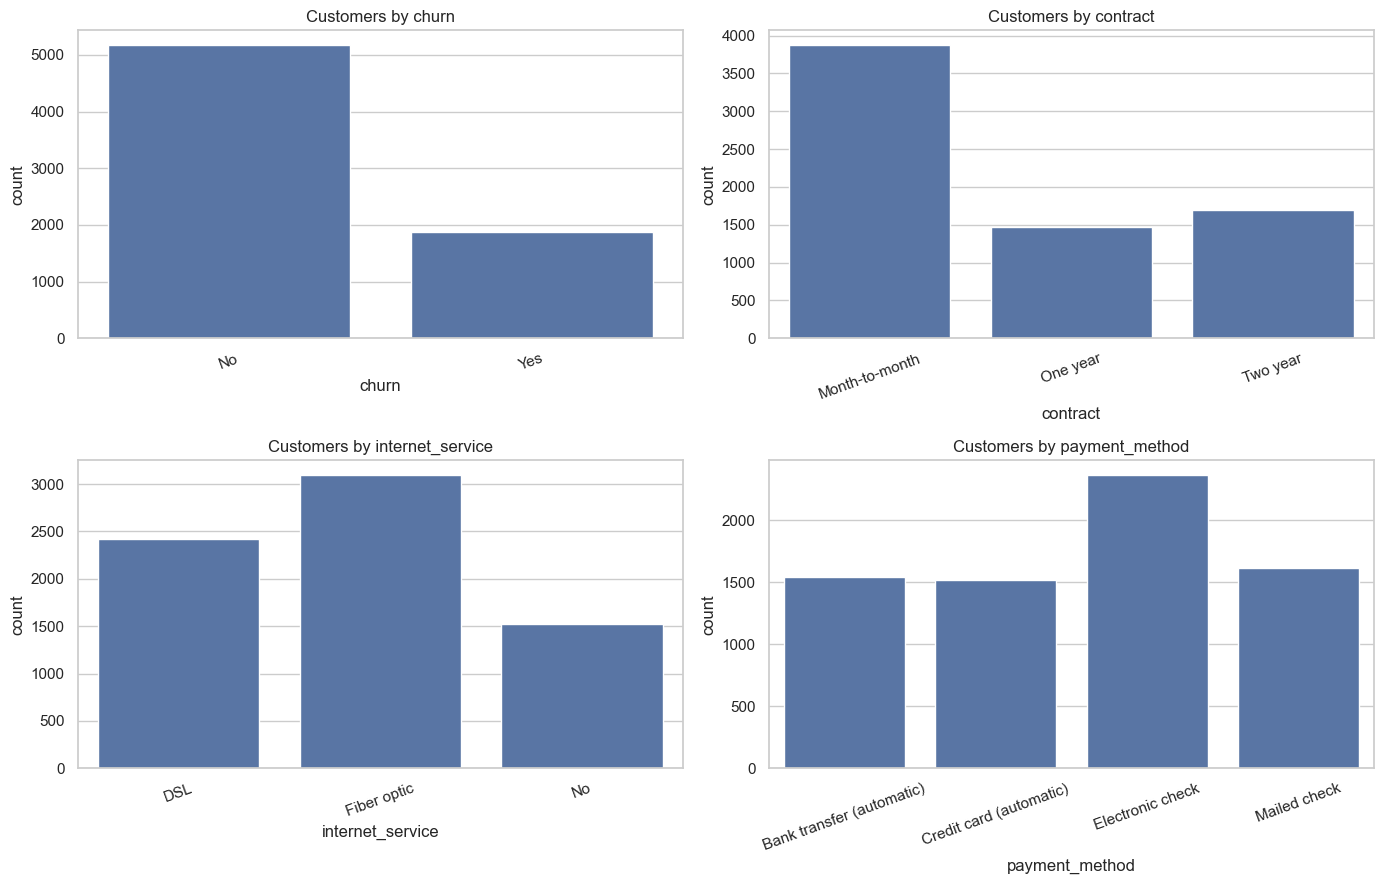

In [23]:
# Bar charts
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), ["churn", "contract", "internet_service", "payment_method"]):
    sns.countplot(data=df_eda, x=col, ax=ax)
    ax.set_title(f"Customers by {col}")
    ax.tick_params(axis="x", rotation=20)
save_fig("bar_categorical")

### 3. Bivariate analysis

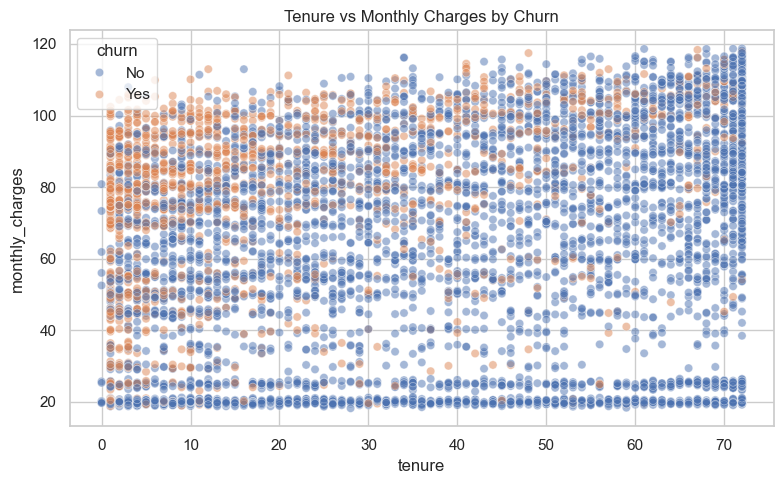

In [24]:
# Scatter plot: tenure vs monthly charges, coloured by churn
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda, x="tenure", y="monthly_charges", hue="churn", alpha=0.5)
plt.title("Tenure vs Monthly Charges by Churn")
save_fig("scatter_tenure_monthly")

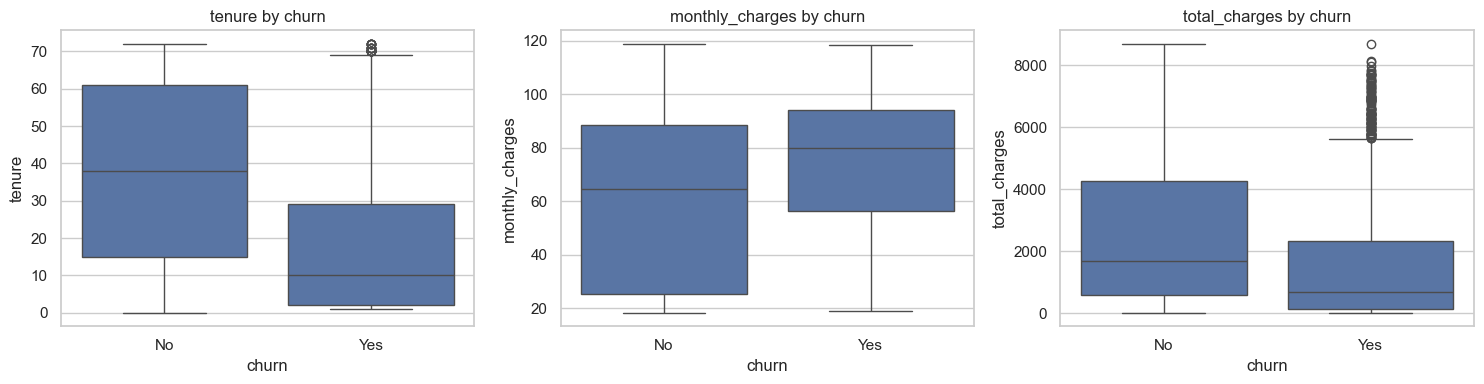

In [25]:
# Numeric features split by churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df_eda, x="churn", y=col, ax=ax)
    ax.set_title(f"{col} by churn")
save_fig("box_by_churn")

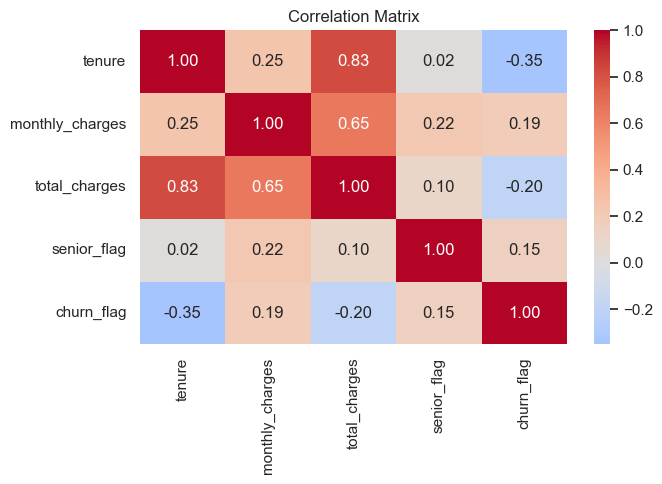

In [26]:
# Correlation heatmap
corr = df_eda[num_cols + ["senior_flag", "churn_flag"]].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
save_fig("correlation_heatmap")

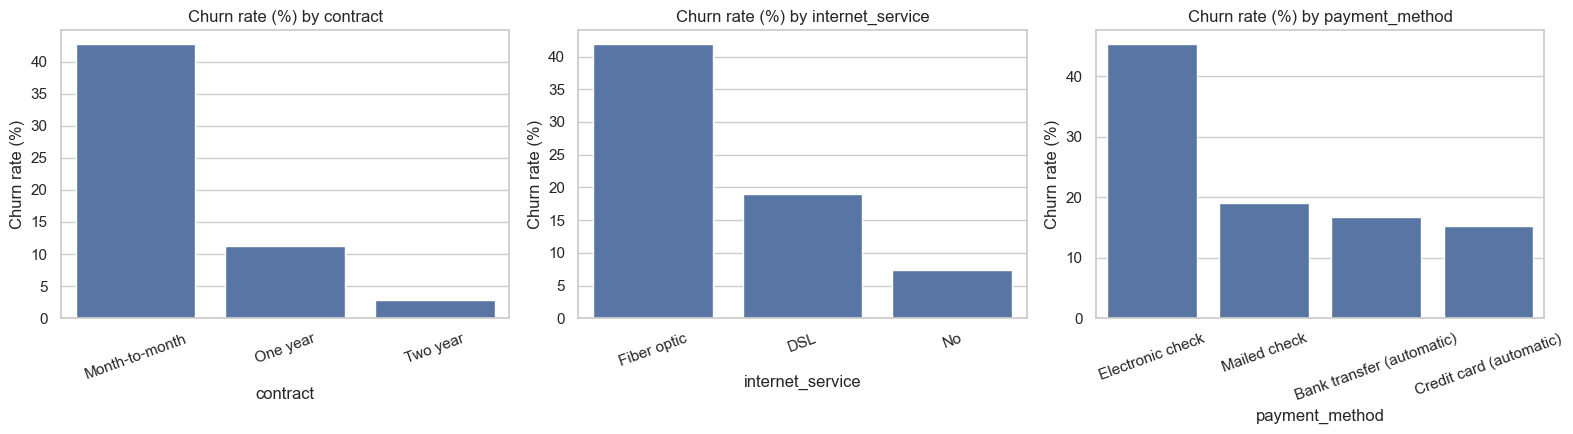

In [27]:
# Churn rate by category
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["contract", "internet_service", "payment_method"]):
    rate = (df_eda.groupby(col, observed=True)["churn_flag"].mean()
            .mul(100).sort_values(ascending=False))
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax)
    ax.set_title(f"Churn rate (%) by {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.tick_params(axis="x", rotation=20)
save_fig("churn_rate_by_category")

### 4. Patterns, trends & anomalies

In [28]:
overall = df_eda["churn_flag"].mean() * 100
by_contract = df_eda.groupby("contract", observed=True)["churn_flag"].mean().mul(100).round(1)
by_internet = df_eda.groupby("internet_service", observed=True)["churn_flag"].mean().mul(100).round(1)
tenure_median = df_eda.groupby("churn", observed=True)["tenure"].median()
monthly_mean = df_eda.groupby("churn", observed=True)["monthly_charges"].mean().round(1)

print(f"Overall churn rate: {overall:.1f}%\n")
print("Churn rate by contract (%):\n", by_contract, "\n")
print("Churn rate by internet service (%):\n", by_internet, "\n")
print("Median tenure (months) by churn:\n", tenure_median, "\n")
print("Mean monthly charges by churn:\n", monthly_mean, "\n")
print("Correlation with churn:\n", corr["churn_flag"].drop("churn_flag").round(2))
print("\nCorr(tenure, total_charges):", round(corr.loc["tenure", "total_charges"], 2))

Overall churn rate: 26.5%

Churn rate by contract (%):
 contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: churn_flag, dtype: float64 

Churn rate by internet service (%):
 internet_service
DSL            19.0
Fiber optic    41.9
No              7.4
Name: churn_flag, dtype: float64 

Median tenure (months) by churn:
 churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64 

Mean monthly charges by churn:
 churn
No     61.3
Yes    74.4
Name: monthly_charges, dtype: float64 

Correlation with churn:
 tenure            -0.35
monthly_charges    0.19
total_charges     -0.20
senior_flag        0.15
Name: churn_flag, dtype: float64

Corr(tenure, total_charges): 0.83


### 5. Key findings
*Replace the bracketed values with the numbers printed above.*

1. **Contract type drives churn:** Month-to-month customers churn at **[X]%**, versus **[Y]%** on one-year and **[Z]%** on two-year contracts.
2. **New customers leave first:** Median tenure is **[A]** months for churned customers versus **[B]** months for retained ones.
3. **Higher bills, higher churn:** Churned customers pay more per month on average (**$[C]** vs **$[D]**), and **[fiber optic]** customers show the highest churn rate (**[E]%**).

**Anomalies / notes:** `total_charges` is almost perfectly driven by `tenure` (r = **[r]**), so avoid using both in a model. Outliers were kept because they are valid customers.

### 6. Save cleaned data

In [29]:
df_clean.to_csv(PROCESSED, index=False)
print("Saved cleaned data to", PROCESSED, "| shape:", df_clean.shape)

Saved cleaned data to ..\data\processed\telco_churn_clean.csv | shape: (7043, 21)
